# 日経平均株価 先物（CME日経先物 円建て）15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import pandas as pd
import yfinance as yf

In [3]:
symbol = "NIY=F"
ticker1 = yf.Ticker(symbol)
df = ticker1.history(period="1d", interval="15m")
df.index = df.index.tz_convert("Asia/Tokyo")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-18 13:00:00+09:00,71435.0,71490.0,71350.0,71350.0,177,0.0,0.0
2026-06-18 13:15:00+09:00,71350.0,71390.0,71260.0,71340.0,295,0.0,0.0
2026-06-18 13:30:00+09:00,71330.0,71390.0,71255.0,71295.0,172,0.0,0.0
2026-06-18 13:45:00+09:00,71250.0,71310.0,71180.0,71255.0,377,0.0,0.0
2026-06-18 14:00:00+09:00,71260.0,71380.0,71205.0,71280.0,153,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-19 04:45:00+09:00,72160.0,72205.0,72050.0,72055.0,588,0.0,0.0
2026-06-19 05:00:00+09:00,72055.0,72070.0,71985.0,72030.0,223,0.0,0.0
2026-06-19 05:15:00+09:00,72035.0,72095.0,72030.0,72080.0,39,0.0,0.0


In [4]:
# 先頭のタイムスタンプ（例：金曜のどこかの時刻）
dt0 = df.index[0]

# 金曜の日付だけを取り出す
fri = dt0.normalize()  # 00:00 に丸める

# 開始・終了
dt_start = fri + pd.Timedelta(hours=15, minutes=30)
dt_end = fri + pd.Timedelta(days=1, hours=6)
print(dt_start)
print(dt_end)

df = df[(dt_start <= df.index) & (df.index < dt_end)]
df

2026-06-18 15:30:00+09:00
2026-06-19 06:00:00+09:00


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-18 15:30:00+09:00,71260.0,71265.0,71130.0,71235.0,600,0.0,0.0
2026-06-18 15:45:00+09:00,71250.0,71425.0,71250.0,71425.0,268,0.0,0.0
2026-06-18 16:00:00+09:00,71440.0,71540.0,71355.0,71365.0,423,0.0,0.0
2026-06-18 16:15:00+09:00,71375.0,71540.0,71370.0,71525.0,280,0.0,0.0
2026-06-18 16:30:00+09:00,71520.0,71540.0,71455.0,71540.0,101,0.0,0.0
2026-06-18 16:45:00+09:00,71545.0,71585.0,71465.0,71575.0,270,0.0,0.0
2026-06-18 17:00:00+09:00,71580.0,71725.0,71570.0,71640.0,527,0.0,0.0
2026-06-18 17:15:00+09:00,71630.0,71630.0,71415.0,71415.0,340,0.0,0.0
2026-06-18 17:30:00+09:00,71410.0,71510.0,71355.0,71485.0,344,0.0,0.0


In [5]:
year_str = f"{dt_end.year:04d}"
month_str = f"{dt_end.month:02d}"
day_str = f"{dt_end.day:02d}"
output_path = os.path.join(year_str, month_str, day_str)
os.makedirs(output_path, exist_ok=True)
output_path

'2026/06/19'

## ローソク足チャート（小さいサイズ）

In [6]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

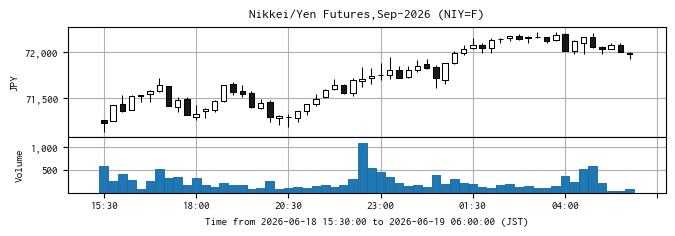

In [7]:
fig = plt.figure(figsize=(6.8, 2.4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[2 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    volume=ax[1],
    ax=ax[0],
)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax[1].set_xlabel(
    f"Time from {dt_start.replace(tzinfo=None)} "
    f"to {dt_end.replace(tzinfo=None)} (JST)"
)
ax[0].set_ylabel("JPY")

if "shortName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['shortName']} ({symbol})")
elif "longName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['longName']} ({symbol})")
else:
    ax[0].set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"15min_chart_{symbol}.png"))
plt.show()